In [3]:
import vbjax as vb
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import time
import sys
import os
import pandas as pd
import seaborn as sns
import tqdm
import jax.example_libraries.optimizers as jopt
from jax.scipy.special import kl_div
import networkx as nx
from copy import deepcopy
from scipy.stats import ks_2samp, entropy

c[vbjax] ███▒▒▒▒▒▒▒ loading
c[vbjax] (ﾉ☉ヮ⚆)ﾉ ⌒*:･ﾟ✧ can haz 14 cores
c[vbjax] ò_ô shtns is not available
c[vbjax] ᕕ(ᐛ)ᕗ ready


In [4]:
cwd = os.getcwd()
functions_path = os.path.join(os.path.dirname(cwd), 'functions')
if functions_path not in sys.path:
    sys.path.append(functions_path)
import site
# Add user site-packages path manually
site_user_base = site.getusersitepackages()
if site_user_base not in sys.path:
    sys.path.append(site_user_base)
import mpr_jax
import FCD_jax
import utils
from importlib import reload
mpr_jax=reload(mpr_jax)
FCD_jax=reload(FCD_jax)

In [15]:
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform" 
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"]="false"
os.environ["JAX_ENABLE_X64"] = "True"

In [16]:
%matplotlib inline

## upload data and parameters, g_target = 0.33

In [17]:
datapath = utils.DATA_ROOT
weights = np.loadtxt(os.path.join(datapath, "weights.txt"))
weights = weights#[:10,:10]
nn = len(weights)
SC = jnp.array(weights) / jnp.max(weights)

true_g = 0.0

weights=SC
params = {"G": true_g, 
          "weights": weights,
          "t_end": 200_000, #t_end 300_000, cut 10_000, tr 500
          "dt": 0.01,
          "eta": jnp.array([-4.6]),
          "rv_decimate": 10,
          "noise_amp": 0.037,
          "tr": 300.0, # set to 500 to subsaple BOLD
          "seed":42
          }

wwidth = 30  # must be < 60
maxNwindows = 300
olap = 0.94
cut = 50 #number of initial time points discarded from the BOLD signal (if BOLD was subsampled, discard 20 or 50 only)
tr = 1

g_values = np.arange(0., 1.5, 0.05) #normally the step is 0.05 instead of 2

In [5]:
def timer(func):
    def wrapper(*args, **kwargs):
        import time
        start = time.time()
        result = func(*args, **kwargs)
        print(f"{func.__name__} took {time.time() - start:.2f} seconds")
        return result
    return wrapper

@timer
def wrapper(g, par, close=True):
    par = deepcopy(par)
    par["G"] = g
    # Create JAX simulation object
    sde = mpr_jax.MPR_sde.create(par)
    data = sde.run({})
    rv_t = data["rv_t"]
    rv_d = data["rv_d"]
    nn = par["weights"].shape[0]
    r = rv_d[:, :nn]
    v = rv_d[:, nn:]
    bold_d = data["bold_d"]
    bold_t = data["bold_t"]
    return rv_t, r, v, bold_t, bold_d

In [19]:
rv_t, r, v, bold_t, bold_d =  wrapper(true_g, params)

noise_r.shape = (Array(10000, dtype=int32), Array(88, dtype=int32))
noise_v.shape = (Array(10000, dtype=int32), Array(88, dtype=int32))
P.initial_state.shape = (Array(176, dtype=int32),)
noise_r.shape = (Array(10000, dtype=int32), Array(88, dtype=int32))
noise_v.shape = (Array(10000, dtype=int32), Array(88, dtype=int32))
P.initial_state.shape = (Array(176, dtype=int32),)
noise_r.shape = (Array(10000, dtype=int32), Array(88, dtype=int32))
noise_v.shape = (Array(10000, dtype=int32), Array(88, dtype=int32))
P.initial_state.shape = (Array(176, dtype=int32),)
noise_r.shape = (Array(10000, dtype=int32), Array(88, dtype=int32))
noise_v.shape = (Array(10000, dtype=int32), Array(88, dtype=int32))
P.initial_state.shape = (Array(176, dtype=int32),)
noise_r.shape = (Array(10000, dtype=int32), Array(88, dtype=int32))
noise_v.shape = (Array(10000, dtype=int32), Array(88, dtype=int32))
P.initial_state.shape = (Array(176, dtype=int32),)
noise_r.shape = (Array(10000, dtype=int32), Array(88, dtype=int32

In [8]:
len(jnp.arange(params['t_end'])[::int(params['tr'])])

667

In [9]:
r

Array([[0.3209057 , 1.3994305 , 0.81137705, ..., 0.82627463, 1.2399689 ,
        1.0612622 ],
       [0.33090433, 1.5915787 , 0.666643  , ..., 0.7349729 , 1.2048582 ,
        0.8972814 ],
       [0.21595183, 1.6771246 , 0.52374566, ..., 0.56461394, 1.175751  ,
        0.7766526 ],
       ...,
       [0.25245792, 0.16322581, 0.15708522, ..., 0.        , 0.16692129,
        0.08677065],
       [0.17447026, 0.19786029, 0.11208612, ..., 0.        , 0.11610042,
        0.        ],
       [0.175038  , 0.08519831, 0.03699028, ..., 0.01322256, 0.06054379,
        0.08164939]], dtype=float32)

In [10]:
FC = np.corrcoef(bold_d[cut:].T) #[cut:]

FCD, FCvec,_ = FCD_jax.extract_FCD(bold_d.T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap) #[cut::tr]
BOLD = bold_d

u_FC = FC[jnp.triu_indices_from(FC, k=1)]
zu_FC = (u_FC - np.mean(u_FC)) / np.std(u_FC)
u_FCD = FCD[jnp.triu_indices_from(FCD, k=30)]
#u_FCD = FCD[jnp.triu_indices_from(FCD, k=1)]

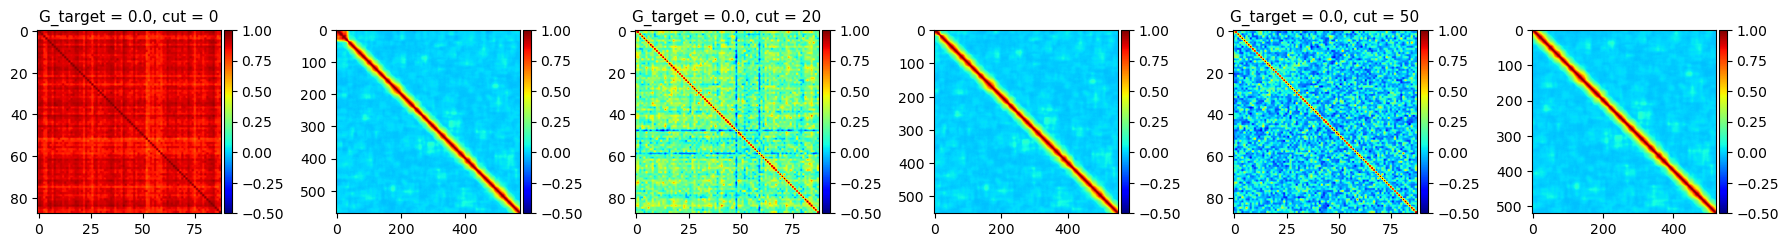

Saved figure to: /home/monica/Desktop/GSoC/repos/GSoC_T3.3_inference/results/2025-12-01/FC_FCD_examples_g_target_0.0_cut_0_20_50_subsampled_t_end_200000.png


In [11]:
cuts = [0, 20, 50]   # starting points
g_true = true_g      # your target G value

fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(18, 4))

for idx, cut in enumerate(cuts):
    # ---- Compute FC & FCD ----
    FC  = np.corrcoef(bold_d[cut:].T)
    FCD, FCvec, _ = FCD_jax.extract_FCD(
        bold_d[cut:].T,
        wwidth=wwidth,
        maxNwindows=maxNwindows,
        olap=olap
    )

    # ----- Left subplot of pair: FC -----
    ax_fc = axes[2*idx]
    im_fc = ax_fc.imshow(FC, vmin=-0.5, vmax=1, cmap='jet')

    # Colorbar matching height
    cax_fc = ax_fc.inset_axes([1.02, 0., 0.04, 1])
    fig.colorbar(im_fc, cax=cax_fc)

    # Title for this FC/FCD pair
    ax_fc.set_title(f"G_target = {g_true}, cut = {cut}", fontsize=11)

    # ----- Right subplot of pair: FCD -----
    ax_fcd = axes[2*idx + 1]
    im_fcd = ax_fcd.imshow(FCD, vmin=-0.5, vmax=1, cmap='jet')

    # Colorbar matching height
    cax_fcd = ax_fcd.inset_axes([1.02, 0., 0.04, 1])
    fig.colorbar(im_fcd, cax=cax_fcd)

plt.tight_layout()

save_path = (
    utils.results_folder() +
    f"/FC_FCD_examples_g_target_{true_g}_cut_0_20_50_subsampled_t_end_{params['t_end']}.png"
)

plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

print("Saved figure to:", save_path)

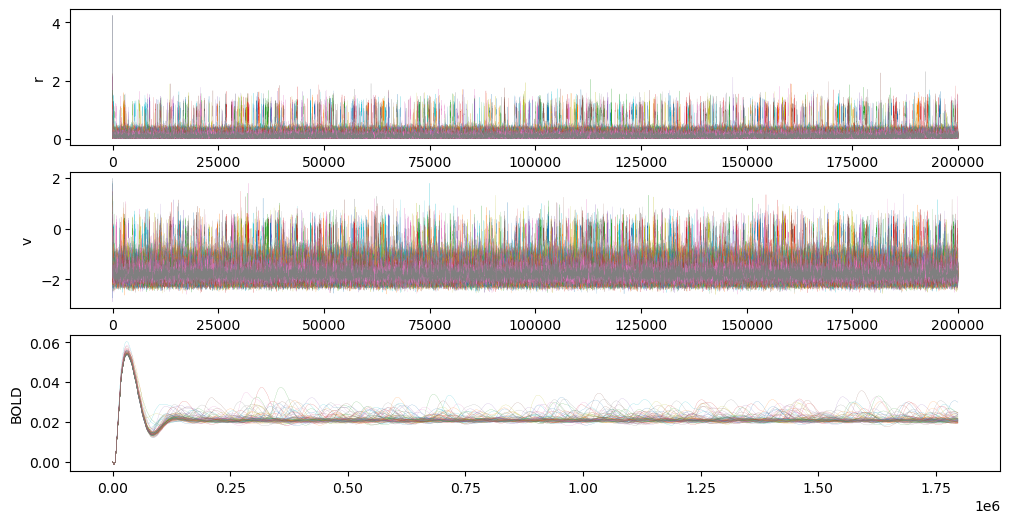

In [12]:
def plot(rv_t, r, v, bold_d, bold_t, close=True):
    step = 10
    fig, ax = plt.subplots(3, 1, figsize=(12, 6))
    ax[0].plot(rv_t[::step], r[::step, :], lw=0.1)
    ax[1].plot(rv_t[::step], v[::step, :], lw=0.1)
    ax[2].plot(bold_t, bold_d, lw=0.1)
    ax[0].set_ylabel("r")
    ax[1].set_ylabel("v")
    ax[2].set_ylabel("BOLD")
    # os.makedirs("data", exist_ok=True)
    # plt.savefig(f"data/control_vbi_{g:.3f}.png")
    # if close:
    #     plt.close()
    plt.show()

plot(rv_t,r,v,bold_d,bold_t)

### simulator, fix g_target = 0.33, cut = 50 and sweep over parameters

In [9]:
@timer
def wrapper_with_key(g, key, par, close=True):
    par = deepcopy(par)
    par["G"] = g
    #par["seed"] = seed
    # Create JAX simulation object
    sde = mpr_jax.MPR_sde.create(par,key)
    data = sde.run({'G':g})
    rv_t = data["rv_t"]
    rv_d = data["rv_d"]
    nn = par["weights"].shape[0]
    r = rv_d[:, :nn]
    v = rv_d[:, nn:]
    bold_d = data["bold_d"]
    bold_t = data["bold_t"]
    return rv_t, r, v, bold_t, bold_d

In [10]:
def run_for_prms_mod(G,key) :

    rv_t, r, v, bold_t, bold_d = wrapper_with_key(G, key, params)

    sim_fc = FCD_jax.get_fc(bold_d[cut:].T) #[cut:]

    sim_fcd, FCvec,_ = FCD_jax.extract_FCD(bold_d.T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap) #[cut::tr]

    sim_u_FC = sim_fc[jnp.triu_indices_from(sim_fc, k=1)]
    sim_zu_FC = (sim_u_FC - np.mean(sim_u_FC)) / np.std(sim_u_FC)
    sim_u_FCD = sim_fcd[jnp.triu_indices_from(sim_fcd, k=30)]
    
    return sim_u_FC, sim_zu_FC, sim_u_FCD

In [11]:
def try_loss_mod_extended(prm, FC_obs_flat, FC_obs_zsco_flat, FCD_obs_flat, key, wwidth=30, olap=0.94, bins=50):
    """
    Compute multiple loss components between simulated and observed FC/FCD.
    """

    losses = {}
    #sim_bold, sim_fc, sim_fcd = run_for_prms_mod(prm, key)
    sim_u_FC, sim_zu_FC, sim_u_FCD = run_for_prms_mod(prm, key)
    
    # mean FC difference
    #losses["mean_fc"] = float((np.mean(obs_fc_np) - np.mean(sim_fc_np)) ** 2)
    losses["mean_fc"] = float((np.mean(FC_obs_flat) - np.mean(sim_u_FC)) ** 2)
    
    # correlation of FC patterns
    r = np.corrcoef(sim_zu_FC, FC_obs_zsco_flat)[0, 1]
    losses["corr_fc"] = float(np.nan_to_num(r, nan=0.0))
    
    # MSE of FC
    losses["mse_fc"] = float(np.mean((FC_obs_flat - sim_u_FC) ** 2))

    # KS distance
    losses["ks_fc"] = float(ks_2samp(FC_obs_flat, sim_u_FC)[0])

    # histogram-based KL divergence
    eps = 1e-8
    p_hist, edges = np.histogram(FC_obs_flat, bins=bins, density=True)
    q_hist, _ = np.histogram(sim_u_FC, bins=edges, density=True)
    p = (p_hist + eps) / (p_hist + eps).sum()
    q = (q_hist + eps) / (q_hist + eps).sum()
    losses["kl_fc_hist"] = float(entropy(p, q))
   
    # variance difference
    losses["var_fcd"] = float((np.var(FCD_obs_flat) - np.var(sim_u_FCD)) ** 2)
    losses["ks_fcd"] = float(ks_2samp(FCD_obs_flat, sim_u_FCD)[0])
    
    # Histogram-based KL for FCD (only on selected upper triangle values)
    eps = 1e-8
    p_hist, edges = np.histogram(FCD_obs_flat, bins=bins, density=True)
    q_hist, _ = np.histogram(sim_u_FCD, bins=edges, density=True)

    p = (p_hist + eps) / (p_hist + eps).sum()
    q = (q_hist + eps) / (q_hist + eps).sum()
    losses["kl_fcd_hist"] = float(entropy(p, q))

    return losses

In [14]:
loss_sweep_mod_extended = {
    'mean_fc': [],
    'corr_fc': [],
    'mse_fc': [],
    'ks_fc': [],
    'kl_fc_hist': [],
    'var_fcd': [],
    'ks_fcd': [],
    'kl_fcd_hist': []
}

for g in g_values :
    key = jax.random.PRNGKey(int(time.time()))
    loss = try_loss_mod_extended(g, u_FC, zu_FC, u_FCD, key)
    for key in loss_sweep_mod_extended.keys() :
        loss_sweep_mod_extended[key].append(loss[key])

NameError: name 'u_FC' is not defined

In [15]:
for key in loss_sweep_mod_extended.keys() :
    loss_sweep_mod_extended[key] = np.array(loss_sweep_mod_extended[key])

ValueError: x and y must have same first dimension, but have shapes (30,) and (0,)

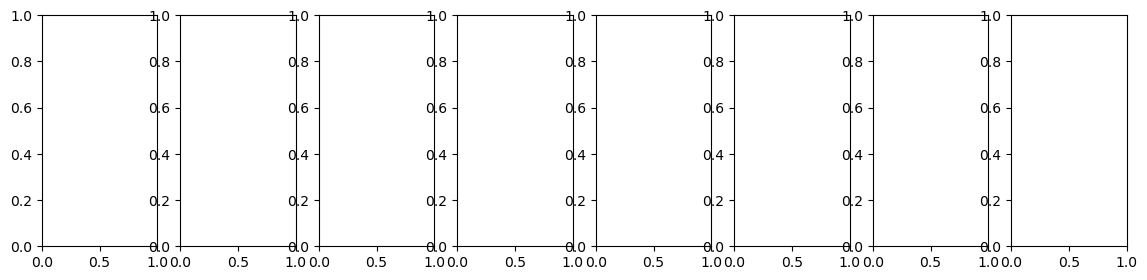

In [16]:
fig, ax = plt.subplots(ncols=len(loss_sweep_mod_extended), figsize=(14, 3))
for i, (k,v) in enumerate(loss_sweep_mod_extended.items()) :
    ax[i].plot(g_values, v)
    ax[i].axvline(true_g, color='r')
    min_index = np.argmin(v)
    #ax[i].axvline(g_values[min_index], color='g')
    ax[i].set(title=k)

### take average on every g of the sweep to smooth loss

In [12]:
def try_loss_mod_extended_vmap(
        prm,
        FC_obs_flat,
        FC_obs_zsco_flat,
        FCD_obs_flat,
        n_sims=5,
        wwidth=30,
        olap=0.94,
        bins=50):

    """
    Compute losses between observed FC/FCD and simulated FC/FCD,
    averaging (actually summing) over many random seeds.

    Inputs are already flattened, so no triangular extraction is done here.
    """

    eps = 1e-8

    # Random keys
    base_key = jax.random.PRNGKey(int(time.time()))
    keys = jax.random.split(base_key, n_sims)

    # Vectorize simulation
    def run_once(key):
        sim_u_FC, sim_zu_FC, sim_u_FCD = run_for_prms_mod(prm, key)
        return sim_u_FC, sim_zu_FC, sim_u_FCD

    sim_u_FC_all, sim_zu_FC_all, sim_u_FCD_all = jax.vmap(run_once)(keys)

    # Move to numpy
    sim_u_FC_all = np.array(sim_u_FC_all)
    sim_zu_FC_all = np.array(sim_zu_FC_all)
    sim_u_FCD_all = np.array(sim_u_FCD_all)

    # Prepare histograms for obs
    p_fc_hist, fc_edges = np.histogram(FC_obs_flat, bins=bins, density=True)
    p_fc = (p_fc_hist + eps) / (p_fc_hist + eps).sum()

    p_fcd_hist, fcd_edges = np.histogram(FCD_obs_flat, bins=bins, density=True)
    p_fcd = (p_fcd_hist + eps) / (p_fcd_hist + eps).sum()

    # --- initialize losses ---
    losses = {
        "mean_fc": 0.0,
        "corr_fc": 0.0,
        "mse_fc": 0.0,
        "ks_fc": 0.0,
        "kl_fc_hist": 0.0,
        "var_fcd": 0.0,
        "ks_fcd": 0.0,
        "kl_fcd_hist": 0.0,
    }

    # --- Loop only on simulations for loss aggregation ---
    for sim_u_FC, sim_zu_FC, sim_u_FCD in zip(sim_u_FC_all, sim_zu_FC_all, sim_u_FCD_all):

        # FC mean
        losses["mean_fc"] += (np.mean(FC_obs_flat) - np.mean(sim_u_FC)) ** 2

        # FC correlation
        r = np.corrcoef(sim_zu_FC, FC_obs_zsco_flat)[0, 1]
        losses["corr_fc"] += np.nan_to_num(r, nan=0.0)

        # FC MSE
        losses["mse_fc"] += np.mean((FC_obs_flat - sim_u_FC) ** 2)

        # FC KS
        losses["ks_fc"] += ks_2samp(FC_obs_flat, sim_u_FC)[0]

        # FC KL
        q_hist, _ = np.histogram(sim_u_FC, bins=fc_edges, density=True)
        q = (q_hist + eps) / (q_hist + eps).sum()
        losses["kl_fc_hist"] += entropy(p_fc, q)

        # FCD variance
        losses["var_fcd"] += (np.var(FCD_obs_flat) - np.var(sim_u_FCD)) ** 2

        # FCD KS
        losses["ks_fcd"] += ks_2samp(FCD_obs_flat, sim_u_FCD)[0]

        # FCD KL
        q_hist, _ = np.histogram(sim_u_FCD, bins=fcd_edges, density=True)
        q = (q_hist + eps) / (q_hist + eps).sum()
        losses["kl_fcd_hist"] += entropy(p_fcd, q)

    return losses

### g_target = 0.33

In [ ]:
losses = {
    'mean_fc': [],
    'corr_fc': [],
    'mse_fc': [],
    'ks_fc': [],
    'kl_fc_hist': [],
    'var_fcd': [],
    'ks_fcd': [],
    'kl_fcd_hist': []
}

for g in g_values :
    loss = try_loss_mod_extended_vmap(g, u_FC, zu_FC, u_FCD)
    for key in losses.keys() :
        losses[key].append(loss[key])

wrapper_with_key took 280.92 seconds
wrapper_with_key took 273.43 seconds
wrapper_with_key took 265.12 seconds
wrapper_with_key took 261.68 seconds
wrapper_with_key took 268.94 seconds
wrapper_with_key took 260.26 seconds
wrapper_with_key took 266.32 seconds
wrapper_with_key took 273.94 seconds
wrapper_with_key took 267.62 seconds
wrapper_with_key took 274.08 seconds
wrapper_with_key took 270.26 seconds
wrapper_with_key took 256.25 seconds
wrapper_with_key took 270.31 seconds
wrapper_with_key took 272.10 seconds
wrapper_with_key took 266.04 seconds
wrapper_with_key took 262.18 seconds
wrapper_with_key took 253.00 seconds
wrapper_with_key took 266.50 seconds
wrapper_with_key took 268.85 seconds


In [ ]:
for key in losses.keys() :
    losses[key] = np.array(losses[key])

In [ ]:
fig, ax = plt.subplots(ncols=len(losses), figsize=(14, 3))
for i, (k,v) in enumerate(losses.items()) :
    ax[i].plot(g_values, v)
    ax[i].axvline(0.33, color='r')
    min_index = np.argmin(v)
    #ax[i].axvline(g_values[min_index], color='g')
    ax[i].set(title=k)

### g_target = 0

In [200]:
true_g = 0.0
params = {"G": true_g, 
          "weights": weights,
          "t_end": 200000, #t_end 300_000, cut 10_000, tr 500
          "dt": 0.01,
          "eta": jnp.array([-4.6]),
          "rv_decimate": 10,
          "noise_amp": 0.037,
          "tr": 300.0, # set to 500 to subsaple BOLD
          "seed":42
          }
rv_t, r, v, bold_t, bold_d =  wrapper(true_g, params)

wrapper took 19.94 seconds


In [77]:
FC = np.corrcoef(bold_d[cut:].T)

FCD, FCvec,_ = FCD_jax.extract_FCD(bold_d.T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)
BOLD = bold_d

u_FC = FC[jnp.triu_indices_from(FC, k=1)]
zu_FC = (u_FC - np.mean(u_FC)) / np.std(u_FC)
u_FCD = FCD[jnp.triu_indices_from(FCD, k=30)]

In [ ]:
losses0 = {
    'mean_fc': [],
    'corr_fc': [],
    'mse_fc': [],
    'ks_fc': [],
    'kl_fc_hist': [],
    'var_fcd': [],
    'ks_fcd': [],
    'kl_fcd_hist': []
}

for g in g_values :
    loss0 = try_loss_mod_extended_vmap(g, u_FC, zu_FC, u_FCD)
    for key in losses0.keys() :
        losses0[key].append(loss0[key])

wrapper_with_key took 270.68 seconds
wrapper_with_key took 268.37 seconds
wrapper_with_key took 278.30 seconds
wrapper_with_key took 276.35 seconds
wrapper_with_key took 287.27 seconds
wrapper_with_key took 279.44 seconds
wrapper_with_key took 269.73 seconds
wrapper_with_key took 277.25 seconds
wrapper_with_key took 272.97 seconds
wrapper_with_key took 278.22 seconds
wrapper_with_key took 272.34 seconds
wrapper_with_key took 276.26 seconds
wrapper_with_key took 273.24 seconds
wrapper_with_key took 279.14 seconds
wrapper_with_key took 275.44 seconds
wrapper_with_key took 278.54 seconds
wrapper_with_key took 269.60 seconds
wrapper_with_key took 276.45 seconds
wrapper_with_key took 268.89 seconds
wrapper_with_key took 276.14 seconds
wrapper_with_key took 279.00 seconds
wrapper_with_key took 276.67 seconds
wrapper_with_key took 274.52 seconds
wrapper_with_key took 278.47 seconds
wrapper_with_key took 274.44 seconds
wrapper_with_key took 275.62 seconds
wrapper_with_key took 275.20 seconds
w

In [ ]:
for key in losses0.keys() :
    losses0[key] = np.array(losses0[key])

In [ ]:
fig, ax = plt.subplots(ncols=len(losses0), figsize=(14, 3))
for i, (k,v) in enumerate(losses0.items()) :
    ax[i].plot(g_values, v)
    ax[i].axvline(0.0, color='r')
    min_index = np.argmin(v)
    #ax[i].axvline(g_values[min_index], color='g')
    ax[i].set(title=k)

### g_target = 0.5

In [39]:
true_g = 0.5
params = {"G": true_g, 
          "weights": weights,
          "t_end": 200000, #t_end 300_000, cut 10_000, tr 500
          "dt": 0.01,
          "eta": jnp.array([-4.6]),
          "rv_decimate": 10,
          "noise_amp": 0.037,
          "tr": 500.0, # set to 500 to subsaple BOLD
          "seed":42
          }
rv_t, r, v, bold_t, bold_d =  wrapper(true_g, params)

wrapper took 9.33 seconds


In [61]:
FC = np.corrcoef(bold_d[cut:].T)

FCD, FCvec,_ = FCD_jax.extract_FCD(bold_d.T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)
BOLD = bold_d

u_FC = FC[jnp.triu_indices_from(FC, k=1)]
zu_FC = (u_FC - np.mean(u_FC)) / np.std(u_FC)
u_FCD = FCD[jnp.triu_indices_from(FCD, k=30)]

In [ ]:
losses05 = {
    'mean_fc': [],
    'corr_fc': [],
    'mse_fc': [],
    'ks_fc': [],
    'kl_fc_hist': [],
    'var_fcd': [],
    'ks_fcd': [],
    'kl_fcd_hist': []
}

for g in g_values :
    loss05 = try_loss_mod_extended_vmap(g, u_FC, zu_FC, u_FCD)
    for key in losses05.keys() :
        losses05[key].append(loss05[key])

wrapper_with_key took 263.55 seconds
wrapper_with_key took 265.02 seconds
wrapper_with_key took 260.95 seconds
wrapper_with_key took 262.36 seconds
wrapper_with_key took 262.48 seconds
wrapper_with_key took 258.63 seconds
wrapper_with_key took 270.09 seconds
wrapper_with_key took 267.24 seconds
wrapper_with_key took 268.77 seconds
wrapper_with_key took 268.96 seconds
wrapper_with_key took 272.53 seconds
wrapper_with_key took 268.15 seconds
wrapper_with_key took 266.12 seconds
wrapper_with_key took 263.96 seconds
wrapper_with_key took 271.18 seconds
wrapper_with_key took 266.91 seconds
wrapper_with_key took 275.15 seconds
wrapper_with_key took 273.00 seconds
wrapper_with_key took 262.91 seconds


In [ ]:
for key in losses05.keys() :
    losses05[key] = np.array(losses05[key])

In [ ]:
fig, ax = plt.subplots(ncols=len(losses05), figsize=(14, 3))
for i, (k,v) in enumerate(losses05.items()) :
    ax[i].plot(g_values, v)
    ax[i].axvline(0.5, color='r')
    min_index = np.argmin(v)
    #ax[i].axvline(g_values[min_index], color='g')
    ax[i].set(title=k)

### g_target = 0.7

In [23]:
true_g = 0.7
params = {"G": true_g, 
          "weights": weights,
          "t_end": 200000, #t_end 300_000, cut 10_000, tr 500
          "dt": 0.01,
          "eta": jnp.array([-4.6]),
          "rv_decimate": 10,
          "noise_amp": 0.037,
          "tr": 300.0, # set to 500 to subsaple BOLD
          "seed":42
          }
rv_t, r, v, bold_t, bold_d =  wrapper(true_g, params)

wrapper took 9.98 seconds


In [24]:
FC = np.corrcoef(bold_d[cut:].T)

FCD, FCvec,_ = FCD_jax.extract_FCD(bold_d.T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)
BOLD = bold_d

u_FC = FC[jnp.triu_indices_from(FC, k=1)]
zu_FC = (u_FC - np.mean(u_FC)) / np.std(u_FC)
u_FCD = FCD[jnp.triu_indices_from(FCD, k=30)]

In [25]:
#plt.plot(v);

In [26]:
losses07 = {
    'mean_fc': [],
    'corr_fc': [],
    'mse_fc': [],
    'ks_fc': [],
    'kl_fc_hist': [],
    'var_fcd': [],
    'ks_fcd': [],
    'kl_fcd_hist': []
}

for g in g_values :
    loss07 = try_loss_mod_extended_vmap(g, u_FC, zu_FC, u_FCD)
    for key in losses07.keys() :
        losses07[key].append(loss07[key])

wrapper_with_key took 42.16 seconds
wrapper_with_key took 42.07 seconds
wrapper_with_key took 41.51 seconds
wrapper_with_key took 41.24 seconds
wrapper_with_key took 41.61 seconds
wrapper_with_key took 41.15 seconds
wrapper_with_key took 41.37 seconds
wrapper_with_key took 42.16 seconds
wrapper_with_key took 41.48 seconds
wrapper_with_key took 41.58 seconds
wrapper_with_key took 41.71 seconds
wrapper_with_key took 41.52 seconds
wrapper_with_key took 42.82 seconds
wrapper_with_key took 42.66 seconds
wrapper_with_key took 42.16 seconds
wrapper_with_key took 41.68 seconds
wrapper_with_key took 42.93 seconds
wrapper_with_key took 44.36 seconds
wrapper_with_key took 49.28 seconds
wrapper_with_key took 41.47 seconds
wrapper_with_key took 45.22 seconds
wrapper_with_key took 54.02 seconds
wrapper_with_key took 43.46 seconds
wrapper_with_key took 45.20 seconds
wrapper_with_key took 49.46 seconds
wrapper_with_key took 41.93 seconds
wrapper_with_key took 50.02 seconds
wrapper_with_key took 41.56 

In [27]:
for key in losses07.keys() :
    losses07[key] = np.array(losses07[key])

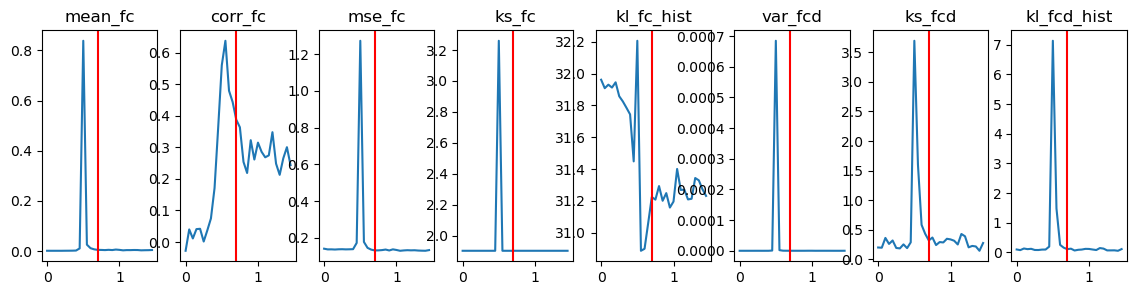

In [30]:
fig, ax = plt.subplots(ncols=len(losses07), figsize=(14, 3))
for i, (k,v) in enumerate(losses07.items()) :
    ax[i].plot(g_values, v)
    ax[i].axvline(0.7, color='r')
    min_index = np.argmin(v)
    #ax[i].axvline(g_values[min_index], color='g')
    ax[i].set(title=k)
#fig.tight_layout(pad=1.0)

## Optimization

In [17]:
datapath = utils.DATA_ROOT
weights = np.loadtxt(os.path.join(datapath, "weights.txt"))
weights = weights#[:10,:10]
nn = len(weights)
SC = jnp.array(weights) / jnp.max(weights)

true_g = 0.0

weights=SC
params = {"G": true_g, 
          "weights": weights,
          "t_end": 30_000, #t_end 300_000, cut 10_000, tr 500
          "dt": 0.01,
          "eta": jnp.array([-4.6]),
          "rv_decimate": 10,
          "noise_amp": 0.037,
          "tr": 300.0, # set to 500 to subsaple BOLD
          "seed":42
          }

wwidth = 30  # must be < 60
maxNwindows = 300
olap = 0.94
cut = 50 #number of initial time points discarded from the BOLD signal (if BOLD was subsampled, discard 20 or 50 only)
tr = 1

g_values = np.arange(0., 1.5, 0.05) #normally the step is 0.05 instead of 2

In [18]:
rv_t, r, v, bold_t, bold_d =  wrapper(true_g, params)

wrapper took 1.59 seconds


In [19]:
FC = np.corrcoef(bold_d[cut:].T) #[cut:]

FCD, FCvec,_ = FCD_jax.extract_FCD(bold_d.T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap) #[cut::tr]
BOLD = bold_d

u_FC = FC[jnp.triu_indices_from(FC, k=1)]
zu_FC = (u_FC - np.mean(u_FC)) / np.std(u_FC)
u_FCD = FCD[jnp.triu_indices_from(FCD, k=30)]
#u_FCD = FCD[jnp.triu_indices_from(FCD, k=1)]

In [20]:
key = jax.random.PRNGKey(int(time.time()))
def loss(G):
    sim_u_FC, sim_zu_FC, sim_u_FCD = run_for_prms_mod(G, key)
    return (jnp.mean(u_FC) - jnp.mean(jnp.nan_to_num(sim_u_FC, nan=0.)))**2

In [21]:
loss(0.6)

wrapper_with_key took 1.60 seconds


Array(0.02837824, dtype=float32)

wrapper_with_key took 1.61 seconds
initial loss 0.04049445


  0%|                                                    | 0/10 [00:00<?, ?it/s]

wrapper_with_key took 2.04 seconds


loss 0.040:  10%|███▏                            | 1/10 [00:02<00:21,  2.38s/it]

wrapper_with_key took 12.06 seconds


...

wrapper_with_key took 12.94 seconds


loss 0.041:  90%|████████████████████████████▊   | 9/10 [01:56<00:13, 13.55s/it]

wrapper_with_key took 13.51 seconds


loss 0.041: 100%|███████████████████████████████| 10/10 [02:10<00:00, 13.04s/it]


Text(0.5, 1.0, 'trace loss')

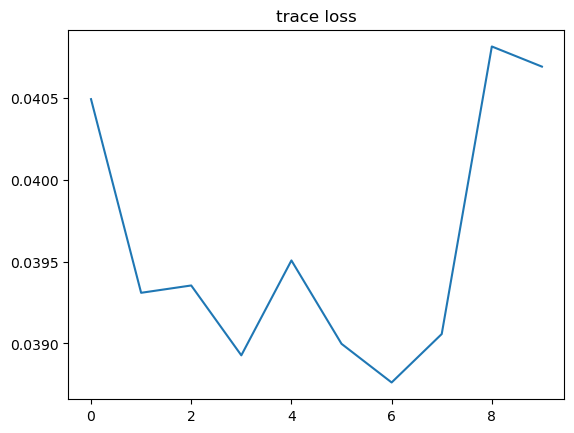

In [28]:
G = 0.3
print('initial loss', loss(G))  # good to check this is finite!

# choose learning rate / optimizer step size
lr = 0.01

# create the optimizer (it returns 3 functions)
opt_init, opt_step, opt_get = jopt.adam(lr)

# create optimizer state
opt = opt_init(G)

# compile the loss function w/ gradients
#vgloss = jax.jit(jax.value_and_grad(loss))
vgloss = jax.value_and_grad(loss)

# do some steps
trace_loss = []
trace_grad = []
trace_params = []
for i in (pbar := tqdm.trange(10)):
    v, g = vgloss(opt_get(opt))
    trace_loss.append(v)
    trace_grad.append(g)
    g = jax.tree_util.tree_map(lambda g: jnp.clip(g, -1, 1), g) # clip stablizes optimization
    opt = opt_step(i, g, opt)
    trace_params.append(opt_get(opt))
    pbar.set_description(f'loss {v:0.3f}')
    
params_final = opt_get(opt)
plt.figure(); plt.plot(trace_loss); plt.title('trace loss')

In [29]:
trace_loss

[Array(0.04049445, dtype=float32),
 Array(0.03930984, dtype=float32),
 Array(0.03935467, dtype=float32),
 Array(0.03892734, dtype=float32),
 Array(0.03950778, dtype=float32),
 Array(0.03899779, dtype=float32),
 Array(0.03876131, dtype=float32),
 Array(0.03905766, dtype=float32),
 Array(0.04081656, dtype=float32),
 Array(0.04069337, dtype=float32)]

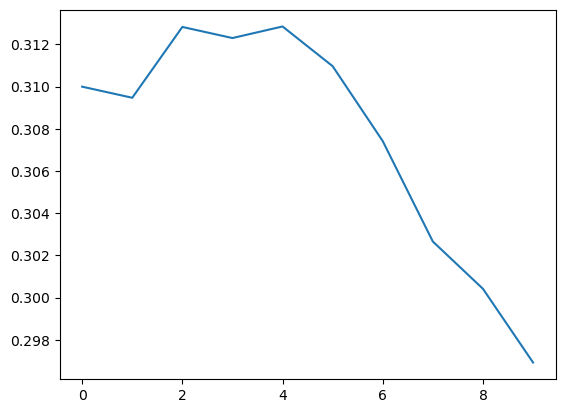

In [33]:
trace_grad
plt.plot(trace_params)

In [31]:
trace_params

[Array(0.30999994, dtype=float32),
 Array(0.30947363, dtype=float32),
 Array(0.31283152, dtype=float32),
 Array(0.3123052, dtype=float32),
 Array(0.31285378, dtype=float32),
 Array(0.31097063, dtype=float32),
 Array(0.3074189, dtype=float32),
 Array(0.30265713, dtype=float32),
 Array(0.3004164, dtype=float32),
 Array(0.2969234, dtype=float32)]

wrapper_with_key took 1.59 seconds
initial loss 0.04049445


  0%|                                                    | 0/10 [00:00<?, ?it/s]

wrapper_with_key took 2.10 seconds


loss 0.040:  10%|███▏                            | 1/10 [00:02<00:22,  2.45s/it]

wrapper_with_key took 12.40 seconds


...

wrapper_with_key took 13.21 seconds


loss 0.042:  90%|████████████████████████████▊   | 9/10 [01:45<00:12, 12.95s/it]

wrapper_with_key took 13.20 seconds


loss 0.042: 100%|███████████████████████████████| 10/10 [01:59<00:00, 11.92s/it]


Text(0.5, 1.0, 'trace loss')

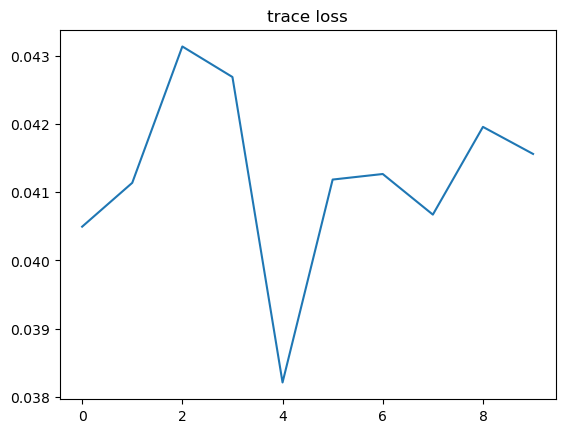

In [34]:
G = 0.3
print('initial loss', loss(G))  # good to check this is finite!

# choose learning rate / optimizer step size
lr = 0.1

# create the optimizer (it returns 3 functions)
opt_init, opt_step, opt_get = jopt.adam(lr)

# create optimizer state
opt = opt_init(G)

# compile the loss function w/ gradients
#vgloss = jax.jit(jax.value_and_grad(loss))
vgloss = jax.value_and_grad(loss)

# do some steps
trace_loss = []
trace_grad = []
trace_params = []
for i in (pbar := tqdm.trange(10)):
    v, g = vgloss(opt_get(opt))
    trace_loss.append(v)
    trace_grad.append(g)
    g = jax.tree_util.tree_map(lambda g: jnp.clip(g, -1, 1), g) # clip stablizes optimization
    opt = opt_step(i, g, opt)
    trace_params.append(opt_get(opt))
    pbar.set_description(f'loss {v:0.3f}')
    
params_final = opt_get(opt)
plt.figure(); plt.plot(trace_loss); plt.title('trace loss')

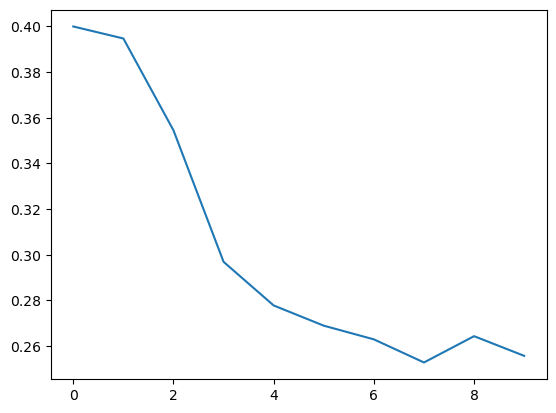

In [38]:
plt.plot(trace_params)

wrapper_with_key took 1.59 seconds
initial loss 0.038176246


  0%|                                                    | 0/20 [00:00<?, ?it/s]

wrapper_with_key took 2.05 seconds


loss 0.038:   5%|█▌                              | 1/20 [00:02<00:45,  2.41s/it]

wrapper_with_key took 12.58 seconds


...

wrapper_with_key took 12.48 seconds


loss 0.040:  95%|█████████████████████████████▍ | 19/20 [03:52<00:12, 12.97s/it]

wrapper_with_key took 12.56 seconds


loss 0.040: 100%|███████████████████████████████| 20/20 [04:05<00:00, 12.25s/it]


Text(0.5, 1.0, 'trace loss')

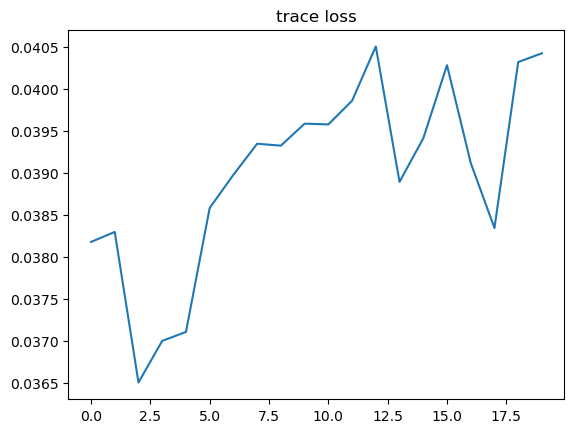

In [41]:
G = 0.2
print('initial loss', loss(G))  # good to check this is finite!

# choose learning rate / optimizer step size
lr = 0.01

# create the optimizer (it returns 3 functions)
opt_init, opt_step, opt_get = jopt.adam(lr)

# create optimizer state
opt = opt_init(G)

# compile the loss function w/ gradients
#vgloss = jax.jit(jax.value_and_grad(loss))
vgloss = jax.value_and_grad(loss)

# do some steps
trace_loss = []
trace_grad = []
trace_params = []
for i in (pbar := tqdm.trange(20)):
    v, g = vgloss(opt_get(opt))
    trace_loss.append(v)
    trace_grad.append(g)
    g = jax.tree_util.tree_map(lambda g: jnp.clip(g, -1, 1), g) # clip stablizes optimization
    opt = opt_step(i, g, opt)
    trace_params.append(opt_get(opt))
    pbar.set_description(f'loss {v:0.3f}')
    
params_final = opt_get(opt)
plt.figure(); plt.plot(trace_loss); plt.title('trace loss')

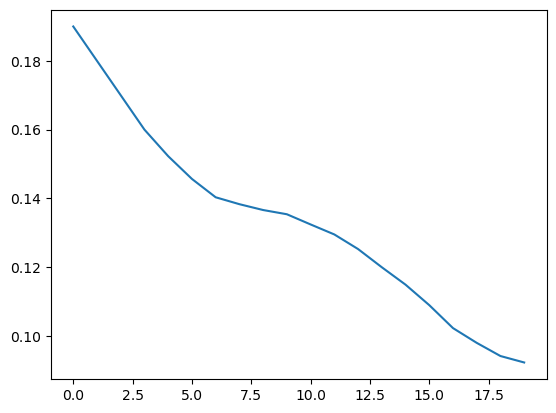

In [43]:
plt.plot(trace_params)

In [21]:
mpr_jax = reload(mpr_jax)

def make_noise_blocks_for_run(sde, par_override, block_size, master_seed=0):

    # === 1) Parameter override like in run() ===
    P = sde.P
    for k, v in par_override.items():
        P = P.replace(**{k: v})

    # run() divides total simulation time by 10
    P = P.replace(t_end=P.t_end/10, t_cut=P.t_cut/10)

    # === 2) Compute block structure ===
    dt = float(P.dt)
    nn = int(P.nn)
    nt_total = int(P.t_end/dt)

    n_full = nt_total // block_size
    remainder = nt_total % block_size
    n_blocks = n_full + (1 if remainder else 0)

    # === 3) Generate fixed-size noise blocks ===
    key = jax.random.PRNGKey(master_seed)
    subkeys = jax.random.sploutsideit(key, 2*n_blocks)

    noise_r_blocks = []
    noise_v_blocks = []

    for b in range(n_blocks):

        steps = block_size if b < n_full else remainder

        kr = subkeys[2*b]
        kv = subkeys[2*b+1]

        # generate real steps
        r = jax.random.normal(kr, (steps, nn)) * P.sigma_r
        v = jax.random.normal(kv, (steps, nn)) * P.sigma_v

        # pad last block if needed
        if steps < block_size:
            pad = block_size - steps
            r = jnp.pad(r, ((0,pad),(0,0)))
            v = jnp.pad(v, ((0,pad),(0,0)))

        noise_r_blocks.append(r)
        noise_v_blocks.append(v)

    return jnp.stack(noise_r_blocks), jnp.stack(noise_v_blocks)


In [22]:
sde = mpr_jax.MPR_sde.create(params)

par_override = {'G':0.3}
block_size   = 10_000              # must match sde.run argument

noise_blocks = make_noise_blocks_for_run(sde, par_override, block_size)
out = sde.run(par=par_override, block_size=block_size, noise_blocks=noise_blocks)


ValueError: Length of slice indices must match number of operand dimensions (1 vs (20000, 88))

In [18]:
np.shape(noise_blocks)

(2, 200, 10000, 88)

In [24]:
(200000/0.01)/10_000

2000.0

In [22]:
(params['t_end']/0.01)/10_000

2000.0

In [26]:
3e3

3000.0

In [30]:
trace_grad

NameError: name 'trace_grad' is not defined

## Bayesian Inference

In [6]:
import errno

import pymc as pm
import pytensor
import pytensor.tensor as pt

from pytensor.compile.ops import as_op
from scipy.integrate import odeint
from scipy.optimize import least_squares

import arviz as az

from tqdm.autonotebook import tqdm as notebook_tqdm


In [20]:
@timer
def wrapper_fc(G, par, cut, starts, nn):
    par = deepcopy(par)
    par["G"] = G
    sde = mpr_jax.MPR_sde.create(par)
    data = sde.run({'G':G}, record_rv=False)
    bold_d = data["bold_d"]

    FC_full = FCD_jax.get_fc(bold_d[int(cut):].T)   
    tri_idx = jnp.triu_indices(FC_full.shape[0], k=1) 
    return FC_full[tri_idx]

@timer
def wrapper_fcd(G, par, cut, starts, nn):
    par = deepcopy(par)
    par["G"] = G
    sde = mpr_jax.MPR_sde.create(par)
    data = sde.run({'G':G}, record_rv=False)
    bold_d = data["bold_d"]

    bold_d_ = bold_d.T

    FCD_full = FCD_jax.extract_FCD_jax_jitted(bold_d, starts, nn, wwidth=30, olap=0.94) 
    tri_idx = jnp.triu_indices(FCD_full.shape[0], k=30)
    return FCD_full[tri_idx]

In [17]:
G = 0.33
t_end = 30_000
cut = 50

wwidth = 30
maxWindows = 200
olap = 0.94

obs_err = 0.01
n_prior = 100
n_warmup = 100
n_samples = 100
n_chains = 2
seed = 0
SC_type = 'data'
SC_size = 88
scale = 1
sampler = 'pathfinder'
which_stat = 'FC' #or FCD

datapath = utils.DATA_ROOT
weights = np.loadtxt(os.path.join(datapath, "weights.txt"))
weights = weights[:10,:10]
nn = len(weights)
con = jnp.array(weights)/jnp.max(weights)


# --- setup model features  and data --
if which_stat == "FC":
    wrapper = wrapper_fc
    #model = model_fc
elif which_stat == "FCD":
    wrapper = wrapper_fcd
    #model = model_fcd
else:
    raise ValueError(f"Invalid Functional Connectivity type '{which_stat}'. Must be 'FC' or 'FCD'.")
    
params = {
    "G": G, "weights": con, "t_end": t_end,
    "dt": 0.01, "eta": jnp.array([-4.6]), "rv_decimate": 10,
    "noise_amp": 0.037, "tr": 1.0, "seed": seed
}

T = t_end-cut#//tr
shift, starts = FCD_jax.precompute_shift_and_starts(T, wwidth=30, olap=0.94)

FC_obs_flat = wrapper(G=G, par=params, cut=cut, starts=starts, nn=nn)
print(FC_obs_flat)
data = {"FC_obs": FC_obs_flat, "params": params, "obs_err": obs_err, "cut": cut, "starts":starts, "nn":nn}
prior_specs = {"mu_G" : 0.5, "sigma": 0.7, "lower": 0}

# --- prior predictive ---
rng_key = jax.random.PRNGKey(seed)

wrapper_fc took 0.94 seconds
[0.8990639  0.93476117 0.98540485 0.9449219  0.9421825  0.94573843
 0.97447944 0.9330433  0.9687609  0.9878701  0.95153373 0.95724446
 0.97770387 0.95890814 0.94819325 0.98023915 0.9556749  0.9777606
 0.9728756  0.9958143  0.97018474 0.97480357 0.99582857 0.9805677
 0.970405   0.9806161  0.96641505 0.9897983  0.97593033 0.9934202
 0.9805082  0.9765424  0.97927016 0.9588096  0.9776841  0.9638589
 0.9796124  0.9926944  0.986912   0.96269524 0.95180637 0.9597204
 0.9720246  0.98585117 0.97644484]


In [18]:
wrapper_fc(G=G, par=params, cut=cut, starts=starts, nn=nn)

wrapper_fc took 0.91 seconds


Array([0.8990639 , 0.93476117, 0.98540485, 0.9449219 , 0.9421825 ,
       0.94573843, 0.97447944, 0.9330433 , 0.9687609 , 0.9878701 ,
       0.95153373, 0.95724446, 0.97770387, 0.95890814, 0.94819325,
       0.98023915, 0.9556749 , 0.9777606 , 0.9728756 , 0.9958143 ,
       0.97018474, 0.97480357, 0.99582857, 0.9805677 , 0.970405  ,
       0.9806161 , 0.96641505, 0.9897983 , 0.97593033, 0.9934202 ,
       0.9805082 , 0.9765424 , 0.97927016, 0.9588096 , 0.9776841 ,
       0.9638589 , 0.9796124 , 0.9926944 , 0.986912  , 0.96269524,
       0.95180637, 0.9597204 , 0.9720246 , 0.98585117, 0.97644484],      dtype=float32)

In [19]:
FCD_obs_flat=wrapper_fcd(G=G, par=params, cut=cut, starts=starts, nn=nn)

TypeError: Slice size at index 1 in gather op is out of range, must be within [0, 10 + 1), got 30.

In [ ]:
theta_true=np.array([0.33])

In [76]:
# decorator with input and output types a Pytensor double float tensors
@as_op(itypes=[pt.dvector], otypes=[pt.dvector])
def pytensor_forward_model_matrix(G):
    result =  wrapper_fc(G=float(np.atleast_1d(G).item()), par=params, cut=cut, starts=starts, nn=nn)
    return np.asarray(result, dtype=np.float64).flatten()

In [63]:
prior_specs

{'mu_G': 0.5, 'sigma': 0.7, 'lower': 0}

In [64]:
with pm.Model() as prior_model:
    G = pm.TruncatedNormal("G", mu=prior_specs["mu_G"], sigma=prior_specs["sigma"], lower=prior_specs["lower"])

In [65]:
with prior_model:
        prior_predict= pm.sample_prior_predictive(n_prior)

Sampling: [G]


In [66]:
def tails_percentile(my_var_names, prior_predictions, thr):
    tails_xth_percentile = {}
    for key, value in prior_predictions.items():
        if key in my_var_names:
            sorted_values = np.sort(value)[0, :] if value.shape[0] == 1 else np.sort(value)
            top_xth_percentile = sorted_values[int(0.05 * len(sorted_values))]
            tails_xth_percentile[key] = np.array(top_xth_percentile)
    return tails_xth_percentile

In [67]:
prior_predict.prior.keys()

KeysView(<xarray.Dataset> Size: 2kB
Dimensions:  (chain: 1, draw: 100)
Coordinates:
  * chain    (chain) int64 8B 0
  * draw     (draw) int64 800B 0 1 2 3 4 5 6 7 8 ... 91 92 93 94 95 96 97 98 99
Data variables:
    G        (chain, draw) float64 800B 0.8208 0.4209 1.1 ... 0.9976 0.5099 0.4
Attributes:
    created_at:                 2025-12-02T01:19:00.572174+00:00
    arviz_version:              0.20.0
    inference_library:          pymc
    inference_library_version:  5.20.0)

<Axes: title={'center': 'G'}>

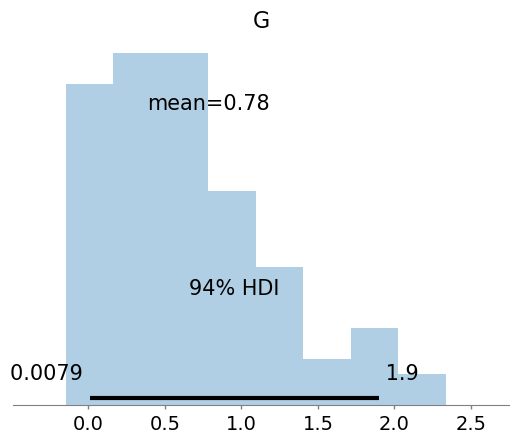

In [68]:
az.plot_posterior(prior_predict, var_names=["G"], group="prior", kind="hist", hdi_prob=0.94)

In [69]:
my_var_names = ['G']
tails_5th_percentile=tails_percentile(my_var_names, prior_predict.prior, 0.05)    
tails_5th_percentile

{'G': array(0.08888723)}

In [70]:
params

{'G': 0.0,
 'weights': Array([[0.        , 0.25199234, 0.00302837, ..., 0.0039847 , 0.00350653,
         0.00223143],
        [0.25199234, 0.        , 0.03889066, ..., 0.01801084, 0.00605674,
         0.01163532],
        [0.00302837, 0.03889066, 0.        , ..., 0.00462225, 0.00207204,
         0.00207204],
        ...,
        [0.0039847 , 0.01801084, 0.00462225, ..., 0.        , 0.11635321,
         0.3970354 ],
        [0.00350653, 0.00605674, 0.00207204, ..., 0.11635321, 0.        ,
         0.20433535],
        [0.00223143, 0.01163532, 0.00207204, ..., 0.3970354 , 0.20433535,
         0.        ]], dtype=float32),
 't_end': 200000,
 'dt': 0.01,
 'eta': Array([-4.6], dtype=float32),
 'rv_decimate': 10,
 'noise_amp': 0.037,
 'tr': 300.0,
 'seed': 42}

In [77]:
with pm.Model() as model:
    # Priors
    G = pm.TruncatedNormal("G", mu=prior_specs["mu_G"], lower=prior_specs["lower"])
    
    params_samples = [G]
    
    # Ode solution function
    FC_hat_flat = pytensor_forward_model_matrix(pm.math.stack(params_samples))

    # Likelihood
    pm.Normal("FC_obs", mu=FC_hat_flat, sigma=obs_err, observed=FC_obs_flat)

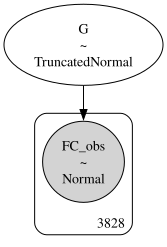

In [78]:
pm.model_to_graphviz(model=model)

In [79]:
(88*88-88)/2

3828.0

In [80]:
model.debug()

point={'G_interval__': array(0.)}

wrapper_fc took 8.90 seconds
No problems found


In [81]:
tune, draws, n_chains = 200, 200, 4

In [82]:
# Variable list to give to the sample step parameter
vars_list = list(model.values_to_rvs.keys())[:-1]

In [101]:
sampler = "Slice Sampler"

start_time = time.time()
with model:
    trace_slice = pm.sample(step=[pm.Slice(vars_list)], tune=5, draws=5, chains=1, 
                            initvals={var_name: tails_5th_percentile[var_name] for var_name in my_var_names}
                           ) 
crudetime_slice=time.time() - start_time
print("---running took: %s seconds ---" % crudetime_slice)

Only 5 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Sequential sampling (1 chains in 1 job)
Slice: [G]


/home/monica/anaconda3/envs/myenv/lib/python3.10/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

wrapper_fc took 1.55 seconds

wrapper_fc took 1.50 seconds

wrapper_fc took 1.63 seconds

...

wrapper_fc took 1.99 seconds

wrapper_fc took 2.18 seconds

wrapper_fc took 2.66 seconds

Sampling 1 chain for 5 tune and 4 draw iterations (5 + 4 draws total) took 175 seconds.
The number of samples is too small to check convergence reliably.


---running took: 175.02683186531067 seconds ---


In [106]:
plt.plot(fcd_obs_flat)

NameError: name 'fcd_obs_flat' is not defined

In [88]:
con = weights/jnp.max(weights)

In [89]:
con

Array([[0.        , 0.25199234, 0.00302837, ..., 0.0039847 , 0.00350653,
        0.00223143],
       [0.25199234, 0.        , 0.03889066, ..., 0.01801084, 0.00605674,
        0.01163532],
       [0.00302837, 0.03889066, 0.        , ..., 0.00462225, 0.00207204,
        0.00207204],
       ...,
       [0.0039847 , 0.01801084, 0.00462225, ..., 0.        , 0.11635321,
        0.3970354 ],
       [0.00350653, 0.00605674, 0.00207204, ..., 0.11635321, 0.        ,
        0.20433535],
       [0.00223143, 0.01163532, 0.00207204, ..., 0.3970354 , 0.20433535,
        0.        ]], dtype=float32)